In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler

In [ ]:
df= pd.read_csv('Telco-Customer-Churn 2.csv')

# DATA CLEANING|



In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# changing dtype of TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')


In [ ]:
df['TotalCharges'].dtype

dtype('float64')

### Encoding Binary Columns

In [ ]:
# Binary Yes/No columns
binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})


# Service-related columns
service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'MultipleLines'
]

for col in service_cols:
    df[col] = df[col].replace({
        'Yes': 1,
        'No': 0,
        'No internet service': 0,
        'No phone service': 0
    })

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


# FEATURE ENGINEERING

In [ ]:
# Customer Lifetime Value
df['CLV'] = df['tenure']*df['MonthlyCharges']

In [ ]:
# Average Revenue Per Month (ARPU)
df['ARPU']= df['TotalCharges']/df['tenure']

df['ARPU']= df['ARPU'].replace([float('inf')],0)

df['ARPU']= df['ARPU'].fillna(0)

In [ ]:
# Service Count
services = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['ServiceCount'] = df[services].sum(axis=1)

In [ ]:
# Engagement Score
minmax_scaler = MinMaxScaler()  
engagement_features = df[['tenure', 'ServiceCount', 'MonthlyCharges']]
scaled_features = minmax_scaler.fit_transform(engagement_features)

In [ ]:
df['EngagementScore']= scaled_features.mean(axis=1)

In [ ]:
# Contract Risk Score
df['ContractRisk'] = df['Contract'].map({
    'Month-to-month': 2,
    'One year': 1,
    'Two year': 0
})


In [ ]:
# Support Dependency
support_services = [
    'TechSupport',
    'OnlineBackup',
    'DeviceProtection'
]

df['SupportDependency']= df[support_services].sum(axis=1)

In [ ]:
# Tenure Group
def tenure_group(tenure):
    
    if tenure <= 12:
        return 'New Customer'
    
    elif tenure <= 36:
        return 'Regular Customer'
    
    elif tenure <= 60:
        return 'Loyal Customer'
    
    else:
        return 'Very Loyal Customer'


df['TenureGroup'] = df['tenure'].apply(tenure_group)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,MonthlyCharges,TotalCharges,Churn,CLV,ARPU,ServiceCount,EngagementScore,ContractRisk,SupportDependency,TenureGroup
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,...,29.85,29.85,0,29.85,29.850000,1,0.084771,2,1,New Customer
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,56.95,1889.50,0,1936.30,55.573529,3,0.410766,1,1,Regular Customer
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,53.85,108.15,1,107.70,54.075000,3,0.252336,2,1,New Customer
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,...,42.30,1840.75,0,1903.50,40.905556,3,0.413101,1,2,Loyal Customer
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,70.70,151.65,1,141.40,75.825000,1,0.224889,2,0,New Customer


# EXPLORATORY DATA ANALYSIS (EDA)


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   str    
 1   gender             7043 non-null   str    
 2   SeniorCitizen      7043 non-null   int64  
 3   Partner            7043 non-null   int64  
 4   Dependents         7043 non-null   int64  
 5   tenure             7043 non-null   int64  
 6   PhoneService       7043 non-null   int64  
 7   MultipleLines      7043 non-null   object 
 8   InternetService    7043 non-null   str    
 9   OnlineSecurity     7043 non-null   object 
 10  OnlineBackup       7043 non-null   object 
 11  DeviceProtection   7043 non-null   object 
 12  TechSupport        7043 non-null   object 
 13  StreamingTV        7043 non-null   object 
 14  StreamingMovies    7043 non-null   object 
 15  Contract           7043 non-null   str    
 16  PaperlessBilling   7043 non-null   

In [ ]:
with pd.option_context('display.max_columns', None):
    display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CLV,ARPU,ServiceCount,EngagementScore,ContractRisk,SupportDependency,TenureGroup
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0,29.85,29.850000,1,0.084771,2,1,New Customer
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0,1936.30,55.573529,3,0.410766,1,1,Regular Customer
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1,107.70,54.075000,3,0.252336,2,1,New Customer
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,1903.50,40.905556,3,0.413101,1,2,Loyal Customer
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,141.40,75.825000,1,0.224889,2,0,New Customer


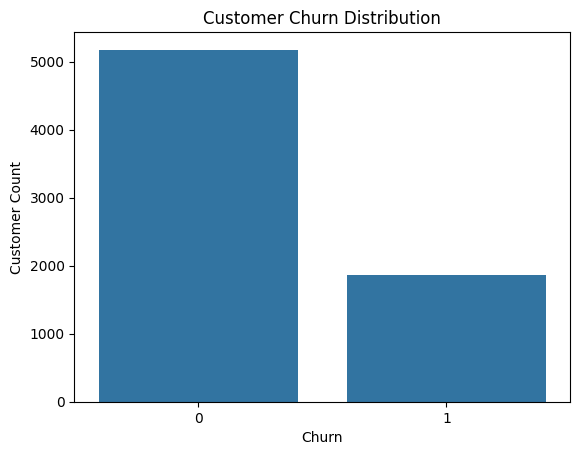

In [ ]:
# Churn Distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Customer Count')

plt.show()

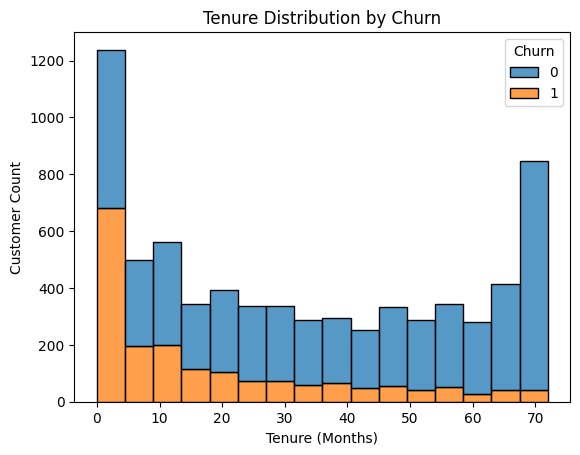

In [ ]:
# Tenure Distribution by Churn
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack')

plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Customer Count')

plt.show()

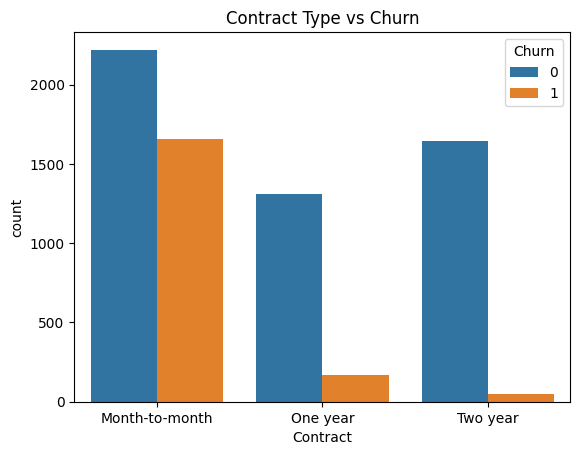

In [ ]:
# Contract Type Analysis
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title('Contract Type vs Churn')

plt.show()

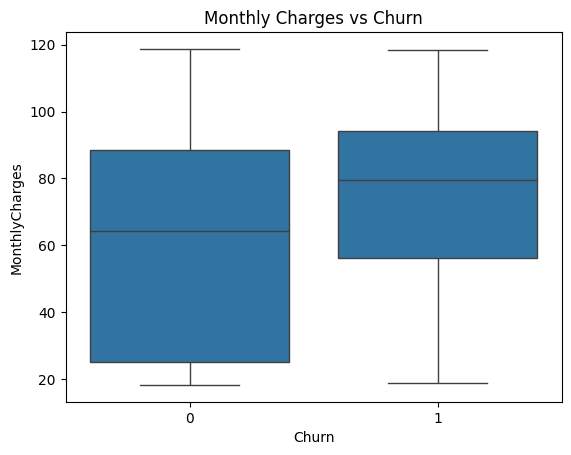

In [ ]:
# Monthly Charges Distribution
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title('Monthly Charges vs Churn')

plt.show()

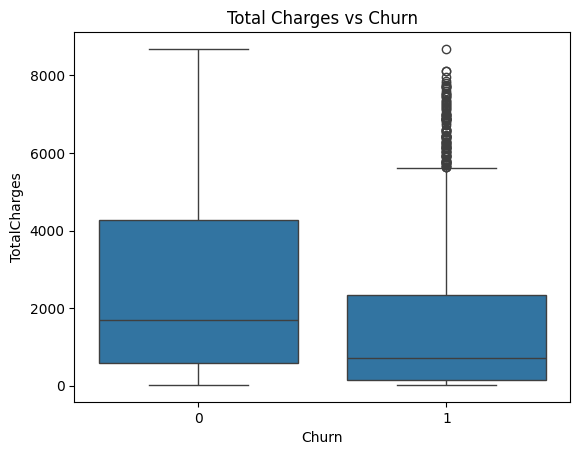

In [ ]:
# Total Charges Comparison
sns.boxplot(x='Churn', y='TotalCharges', data=df)

plt.title('Total Charges vs Churn')

plt.show()

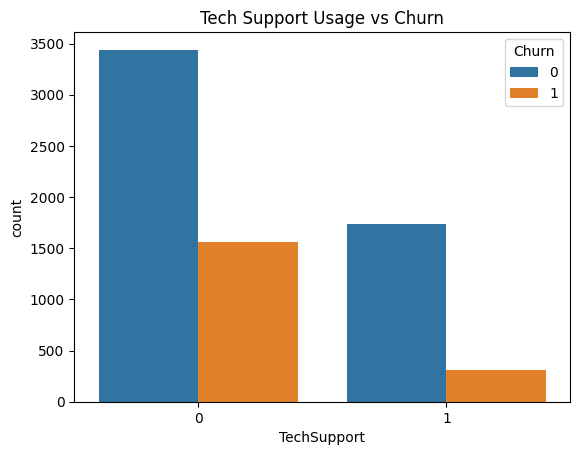

In [ ]:
# Tech Support vs Churn
sns.countplot(x='TechSupport', hue='Churn', data=df)

plt.title('Tech Support Usage vs Churn')

plt.show()

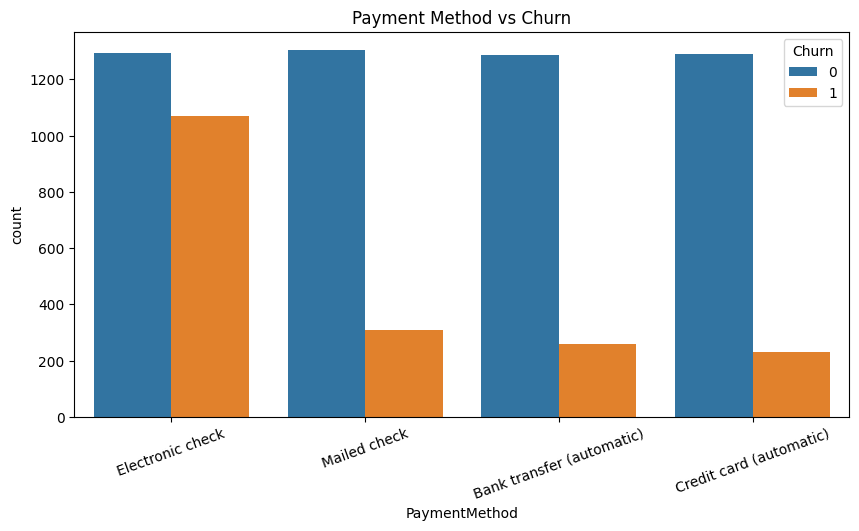

In [ ]:
# Payment Method vs Churn
plt.figure(figsize=(10,5))

sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.xticks(rotation=20)

plt.title('Payment Method vs Churn')

plt.show()

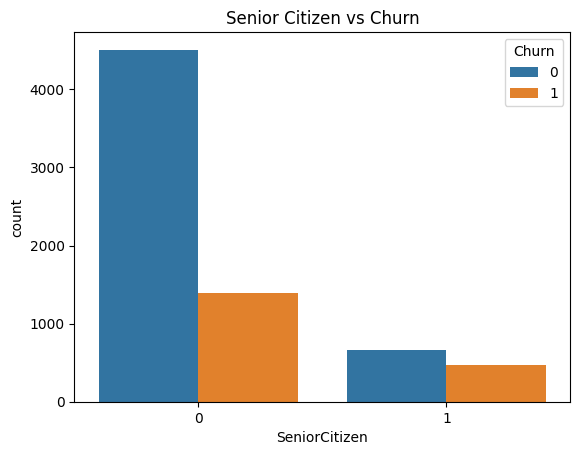

In [ ]:
# Senior Citizen Analysis
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.title('Senior Citizen vs Churn')

plt.show()

In [ ]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=['int64', 'float64'])

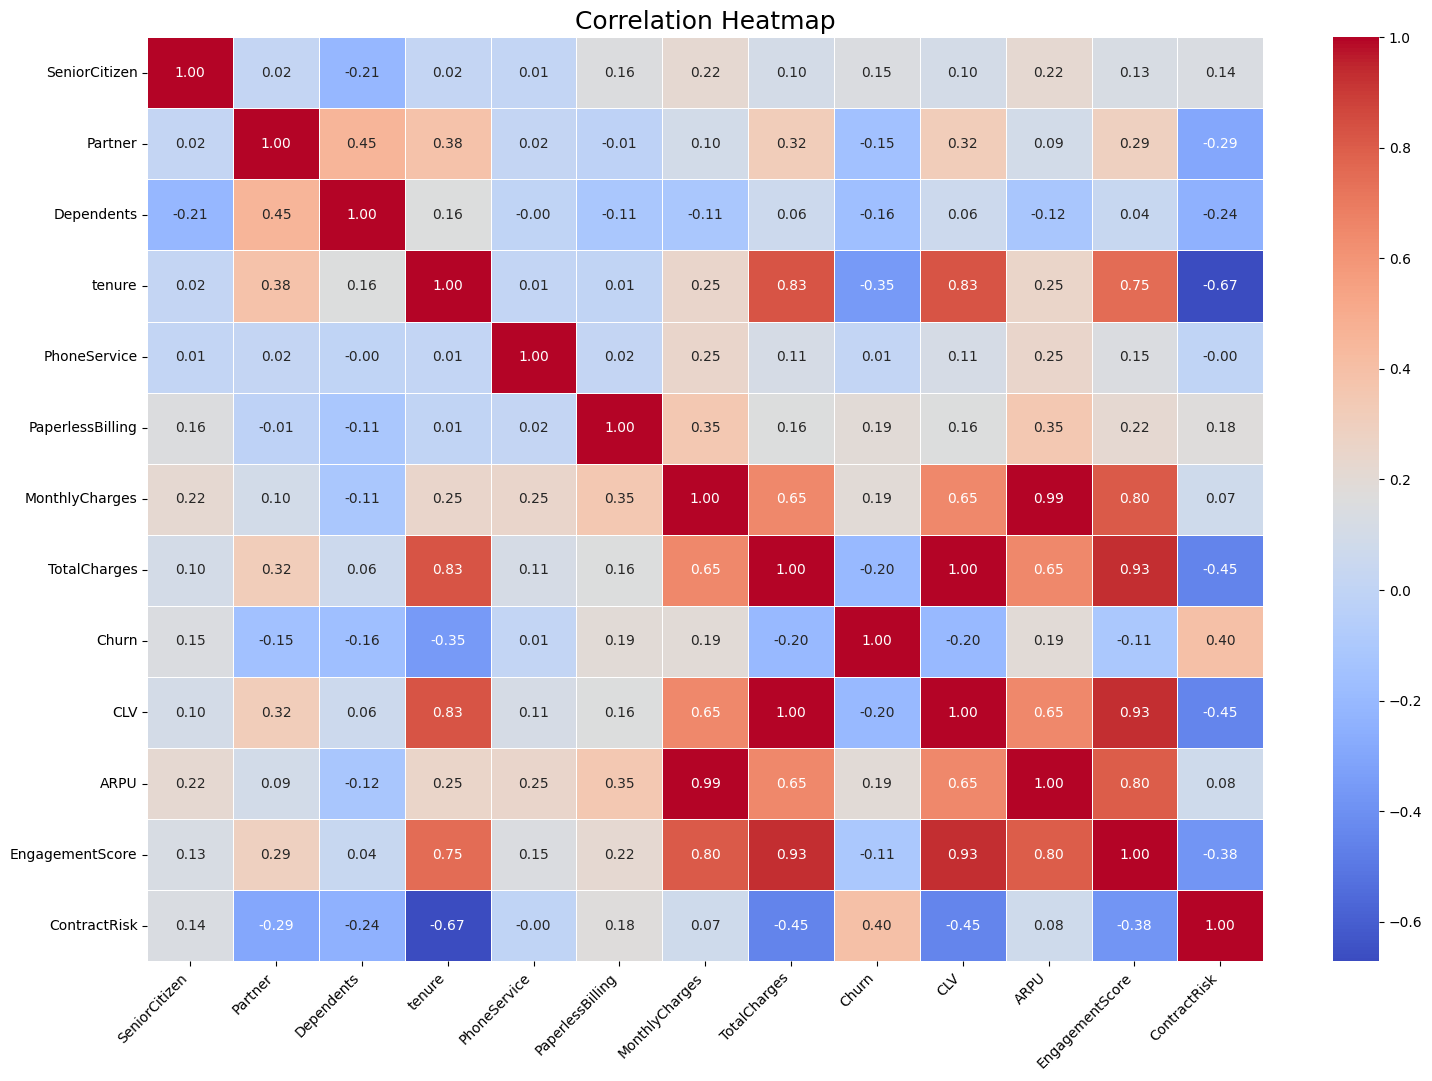

In [ ]:
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title('Correlation Heatmap', fontsize=18)

plt.show()

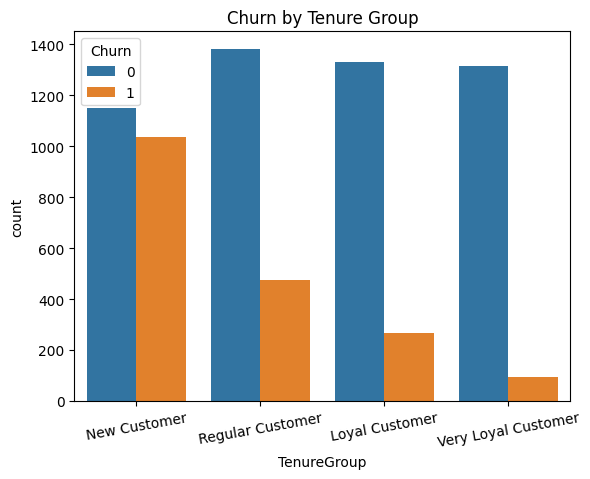

In [ ]:
# ChurnRate by Tenure Group
sns.countplot(x='TenureGroup', hue='Churn', data=df)

plt.xticks(rotation=10)

plt.title('Churn by Tenure Group')

plt.show()

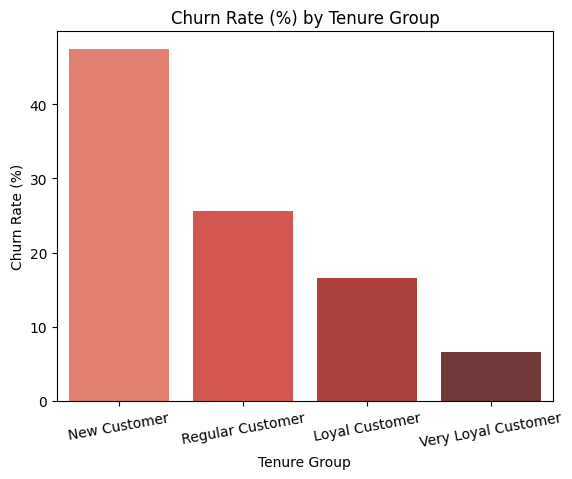

                     ChurnRate
TenureGroup                   
New Customer         47.438243
Regular Customer     25.538793
Loyal Customer       16.624843
Very Loyal Customer   6.609808


In [ ]:
# Churn Rate by Tenure Group (as percentage)
churn_by_tenure = df.groupby('TenureGroup')['Churn'].mean().reset_index()
churn_by_tenure['ChurnRate'] = churn_by_tenure['Churn'] * 100

order = ['New Customer', 'Regular Customer', 'Loyal Customer', 'Very Loyal Customer']

sns.barplot(x='TenureGroup', y='ChurnRate', data=churn_by_tenure, order=order, palette='Reds_d')
plt.title('Churn Rate (%) by Tenure Group')
plt.xticks(rotation=10)
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure Group')
plt.show()

print(churn_by_tenure[['TenureGroup', 'ChurnRate']].set_index('TenureGroup').reindex(order))

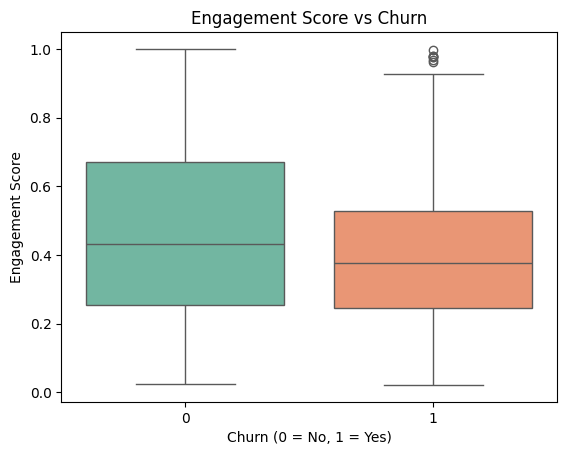

In [ ]:
# EngagementScore vs Churn
sns.boxplot(x='Churn', y='EngagementScore', data=df, palette='Set2')
plt.title('Engagement Score vs Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Engagement Score')
plt.show()

# Customer Segmentation

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select features for segmentation
seg_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'CLV']

seg_df = df[seg_features].copy()

# Scale features
seg_scaler = StandardScaler()  
seg_scaled = seg_scaler.fit_transform(seg_df)


print("Shape:", seg_scaled.shape)
print("Features selected:", seg_features)

Shape: (7043, 5)
Features selected: ['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'CLV']


In [ ]:
# Check and fix NaNs in segmentation features
print("NaNs before fix:", seg_df.isnull().sum())

seg_df = seg_df.dropna()
seg_scaled = seg_scaler.fit_transform(seg_df)

print("Shape after fix:", seg_scaled.shape)

NaNs before fix: tenure             0
MonthlyCharges     0
TotalCharges      11
ServiceCount       0
CLV                0
dtype: int64
Shape after fix: (7032, 5)


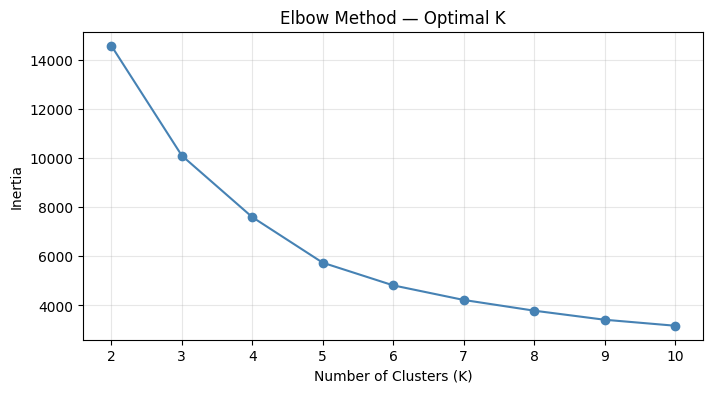

In [ ]:
# Elbow Method to find optimal K
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(seg_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Train KMeans with K=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
seg_df = seg_df.copy()
seg_df['Segment'] = km.fit_predict(seg_scaled)

# Merge segment back to main df
df = df.loc[seg_df.index].copy()
df['Segment'] = seg_df['Segment']

# Profile each segment
segment_profile = df.groupby('Segment').agg(
    CustomerCount=('Segment', 'count'),
    AvgTenure=('tenure', 'mean'),
    AvgMonthlyCharges=('MonthlyCharges', 'mean'),
    AvgCLV=('CLV', 'mean'),
    AvgServiceCount=('ServiceCount', 'mean'),
    ChurnRate=('Churn', 'mean')
).round(2)

segment_profile['ChurnRate'] = (segment_profile['ChurnRate'] * 100).round(1)
print(segment_profile)

         CustomerCount  AvgTenure  AvgMonthlyCharges   AvgCLV AvgServiceCount  \
Segment                                                                         
0                 2122      26.82              26.00   665.49        1.254006   
1                 1280      64.12              97.79  6246.44        6.241406   
2                 2077      10.05              74.22   744.72           2.987   
3                 1553      43.88              78.01  3284.41         4.37669   

         ChurnRate  
Segment             
0             15.0  
1             14.0  
2             50.0  
3             22.0  


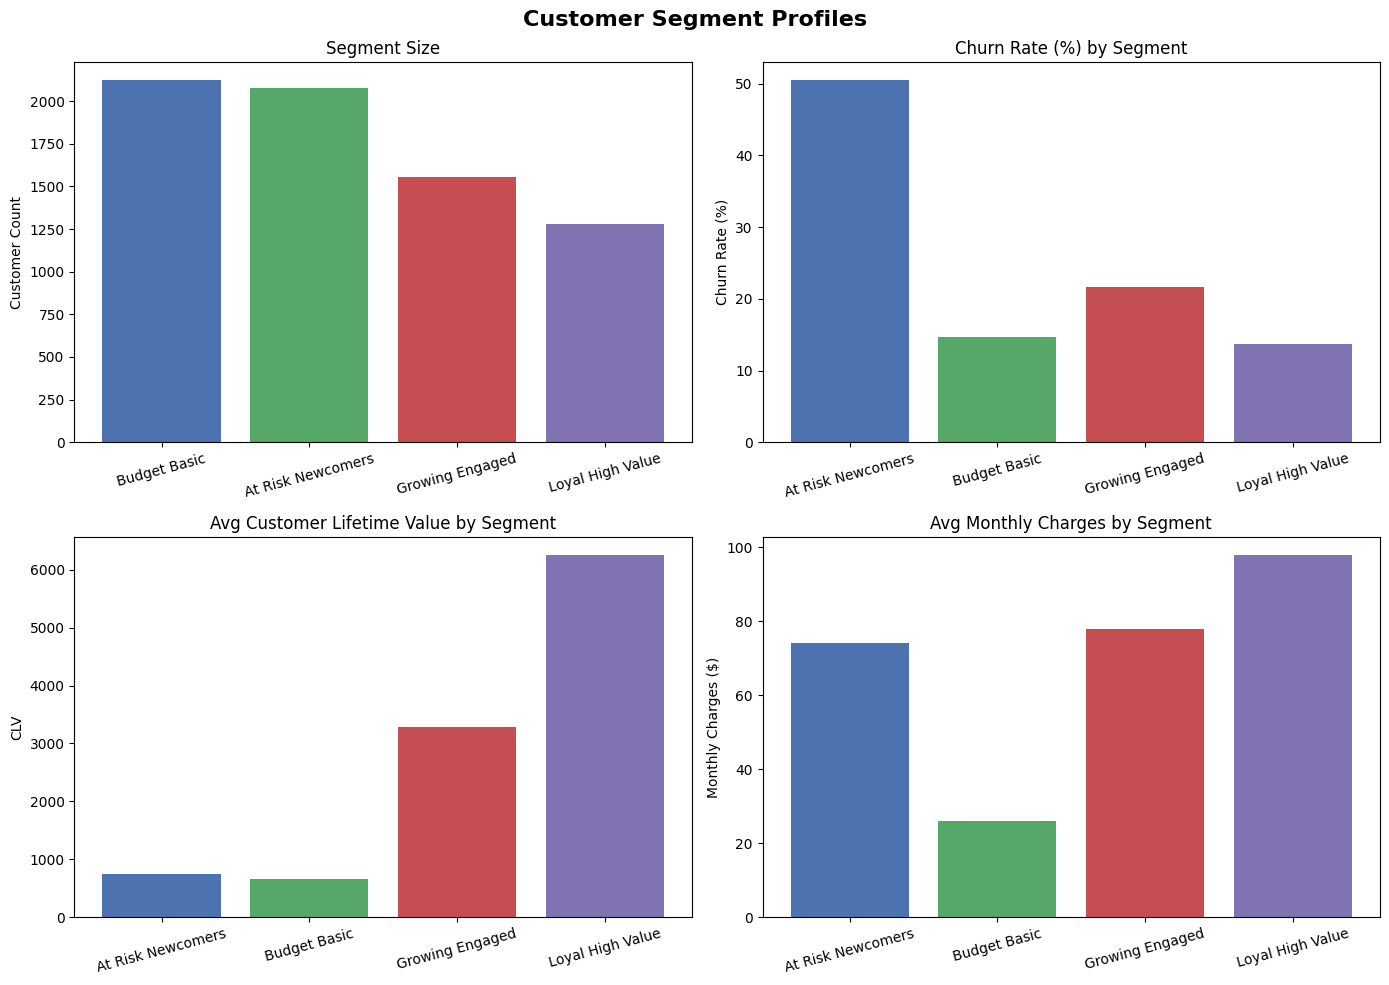

In [ ]:
# Assigning names and visualize
segment_names = {
    0: 'Budget Basic',
    1: 'Loyal High Value',
    2: 'At Risk Newcomers',
    3: 'Growing Engaged'
}

df['SegmentName'] = df['Segment'].map(segment_names)

# Visualize segment profiles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Segment Profiles', fontsize=16, fontweight='bold')

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# 1. Segment Size
seg_counts = df['SegmentName'].value_counts()
axes[0,0].bar(seg_counts.index, seg_counts.values, color=colors)
axes[0,0].set_title('Segment Size')
axes[0,0].set_ylabel('Customer Count')
axes[0,0].tick_params(axis='x', rotation=15)

# 2. Churn Rate by Segment
churn_rates = df.groupby('SegmentName')['Churn'].mean() * 100
axes[0,1].bar(churn_rates.index, churn_rates.values, color=colors)
axes[0,1].set_title('Churn Rate (%) by Segment')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Avg CLV by Segment
clv_avg = df.groupby('SegmentName')['CLV'].mean()
axes[1,0].bar(clv_avg.index, clv_avg.values, color=colors)
axes[1,0].set_title('Avg Customer Lifetime Value by Segment')
axes[1,0].set_ylabel('CLV')
axes[1,0].tick_params(axis='x', rotation=15)

# 4. Avg Monthly Charges by Segment
charges_avg = df.groupby('SegmentName')['MonthlyCharges'].mean()
axes[1,1].bar(charges_avg.index, charges_avg.values, color=colors)
axes[1,1].set_title('Avg Monthly Charges by Segment')
axes[1,1].set_ylabel('Monthly Charges ($)')
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Churn Prediction

In [ ]:
from sklearn.model_selection import train_test_split

# Drop columns not useful for prediction
drop_cols = ['customerID', 'Segment', 'SegmentName', 'TenureGroup', 'ARPU']

df_model = df.drop(columns=drop_cols)

# One-hot encode remaining categorical columns
df_model = pd.get_dummies(df_model, drop_first=True)

# Define X and y
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Churn rate in train:", y_train.mean().round(3))
print("Churn rate in test:", y_test.mean().round(3))

X_train shape: (5625, 37)
X_test shape: (1407, 37)
Churn rate in train: 0.266
Churn rate in test: 0.266


### Train Logistic Regression (Model 1)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Train
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Evaluate
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr).round(4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.63      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



AttributeError: 'float' object has no attribute 'round'

### Train Random Forest (Model 2)

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407

ROC-AUC: 0.8179


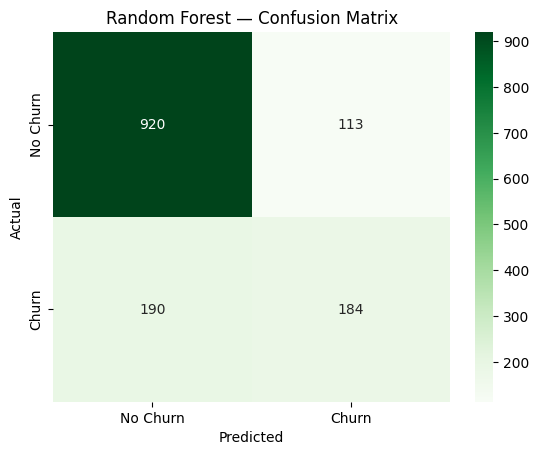

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Evaluate
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf).round(4))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Gradient Boost (Model 3)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

# Train Gradient Boosting
gbm = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbm.fit(X_train, y_train)

y_pred_gbm = gbm.predict(X_test)
y_prob_gbm = gbm.predict_proba(X_test)[:, 1]

print("=== Gradient Boosting ===")
print(classification_report(y_test, y_pred_gbm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gbm).round(4))

# 5-Fold Cross Validation on all 3 models
print("\n=== 5-Fold Cross Validation (ROC-AUC) ===")
for name, model in [('Logistic Regression', lr), ('Random Forest', rf), ('Gradient Boosting', gbm)]:
    scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    print(f"{name}: mean={scores.mean():.4f}, std={scores.std():.4f}")

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8422

=== 5-Fold Cross Validation (ROC-AUC) ===
Logistic Regression: mean=0.8449, std=0.0112
Random Forest: mean=0.8257, std=0.0113
Gradient Boosting: mean=0.8449, std=0.0092


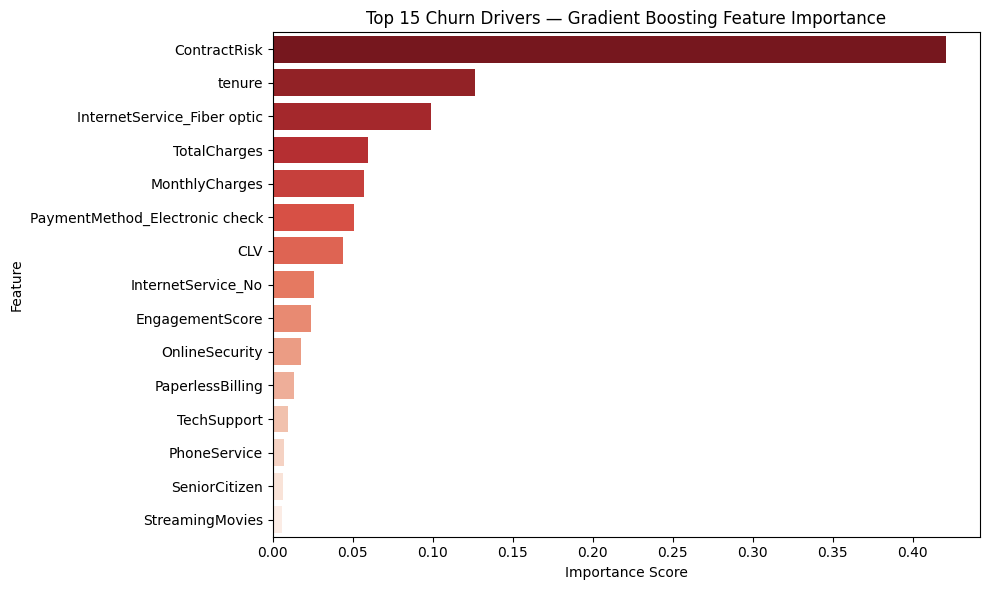

                       Feature  Importance
                  ContractRisk    0.421108
                        tenure    0.126536
   InternetService_Fiber optic    0.099151
                  TotalCharges    0.059758
                MonthlyCharges    0.056761
PaymentMethod_Electronic check    0.050732
                           CLV    0.044106
            InternetService_No    0.025675
               EngagementScore    0.023938
                OnlineSecurity    0.017483
              PaperlessBilling    0.013377
                   TechSupport    0.009595
                  PhoneService    0.007050
                 SeniorCitizen    0.006449
               StreamingMovies    0.005980


In [ ]:
# Feature Importance — Gradient Boosting
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gbm.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='Reds_r')
plt.title('Top 15 Churn Drivers — Gradient Boosting Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feat_imp.to_string(index=False))

### Business Insights table

In [ ]:
insights = {
    'Customer Type':     ['At Risk Newcomers',         'Month-to-Month Users',        'Fiber Optic Users',                'Electronic Check Users',       'Loyal High Value'],
    'Key Finding':       ['50% churn rate',            '#1 churn driver (ContractRisk)','High churn despite premium plan', 'Higher churn than auto-pay',   'Only 14% churn, highest CLV'],
    'Risk Level':        ['🔴 High',                   '🔴 High',                     '🟡 Medium',                        '🟡 Medium',                    '🟢 Low'],
    'Business Action':   ['Improve onboarding & offer early loyalty discount',
                          'Incentivize switch to annual contract',
                          'Investigate service quality issues, offer support',
                          'Nudge toward auto-pay with small discount',
                          'Reward with loyalty program, protect at all costs']
}

insights_df = pd.DataFrame(insights)

print("=" * 90)
print("BUSINESS INSIGHTS & RETENTION STRATEGY")
print("=" * 90)
print(insights_df.to_string(index=False))

BUSINESS INSIGHTS & RETENTION STRATEGY
         Customer Type                     Key Finding Risk Level                                   Business Action
     At Risk Newcomers                  50% churn rate     🔴 High Improve onboarding & offer early loyalty discount
  Month-to-Month Users  #1 churn driver (ContractRisk)     🔴 High             Incentivize switch to annual contract
     Fiber Optic Users High churn despite premium plan   🟡 Medium Investigate service quality issues, offer support
Electronic Check Users      Higher churn than auto-pay   🟡 Medium         Nudge toward auto-pay with small discount
      Loyal High Value     Only 14% churn, highest CLV      🟢 Low Reward with loyalty program, protect at all costs


In [ ]:
import joblib
import json

joblib.dump(gbm, 'churn_model.pkl')
joblib.dump(seg_scaler, 'segmentation_scaler.pkl')
df.to_csv('processed_customers.csv', index=False)

with open('model_features.json', 'w') as f:
    json.dump(list(X.columns), f)

print("All files saved!")

NameError: name 'gbm' is not defined